총 데이터 개수: 2956개
Train 데이터 개수: 2364개, Test 데이터 개수: 592개
X_train shape: (2354, 10, 1), y_train shape: (2354, 1)
X_test shape: (582, 10, 1), y_test shape: (582, 1)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 7.0328e-04 - val_loss: 0.1997
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3011e-05 - val_loss: 0.1961
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1851e-05 - val_loss: 0.1865
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1225e-05 - val_loss: 0.1784
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0088e-05 - val_loss: 0.1665
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9920e-05 - val_loss: 0.1543
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8033e-05 - val_loss: 0.1431
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8155e-05 - val_loss: 0.1325
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6683e-05 - val_loss: 0.1240
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5855e-05 - val_loss: 0.1122
Epoch 11/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4771e-05 - val_loss: 0.1035
Epoch 12/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s

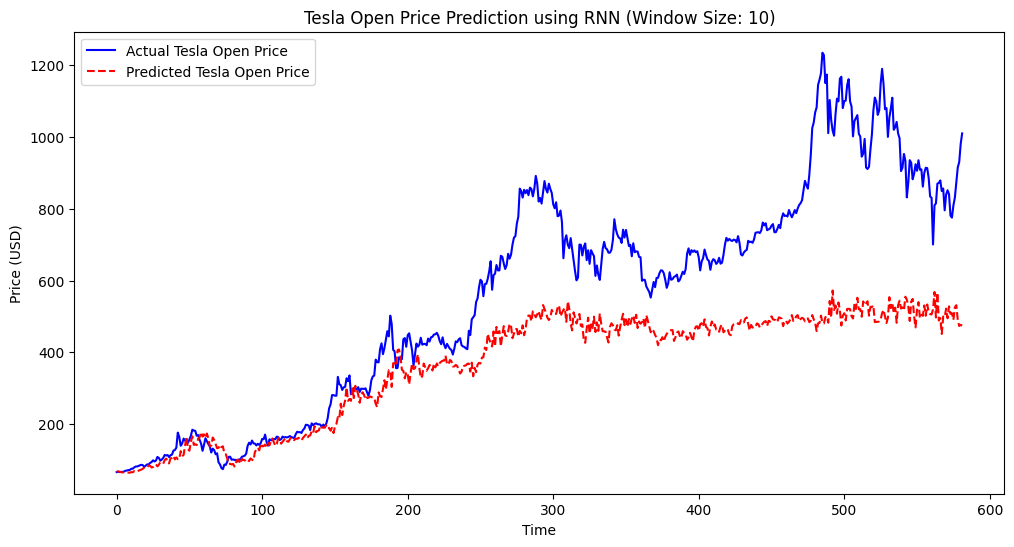

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


df = pd.read_csv('/content/drive/MyDrive/TSLA.csv')
open_prices = df[['Open']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(open_prices)


split_index = int(len(scaled_data) * 0.8)
train_data = scaled_data[:split_index]
test_data = scaled_data[split_index:]

print(f"총 데이터 개수: {len(scaled_data)}개")
print(f"Train 데이터 개수: {len(train_data)}개, Test 데이터 개수: {len(test_data)}개")


def make_sample(data, window_size):
    X, Y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        Y.append(data[i + window_size])
    return np.array(X), np.array(Y)

window_size = 10

X_train, y_train = make_sample(train_data, window_size)
X_test, y_test = make_sample(test_data, window_size)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


model = Sequential()
model.add(SimpleRNN(units=10, activation='tanh', input_shape=(window_size, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)


predicted = model.predict(X_test)

y_test_inverse = scaler.inverse_transform(y_test)
predicted_inverse = scaler.inverse_transform(predicted)

plt.figure(figsize=(12, 6))
plt.plot(y_test_inverse, label='Actual Tesla Open Price', color='blue')
plt.plot(predicted_inverse, label='Predicted Tesla Open Price', color='red', linestyle='--')
plt.title(f'Tesla Open Price Prediction using RNN (Window Size: {window_size})')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()